<a href="https://colab.research.google.com/github/marceloamks/Decision_tree---EBAC/blob/main/Profiss%C3%A3o_Cientista_de_Dados_M17_Pratique_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árvores II - Tarefa I

![image.png](attachment:f65bd82d-aa56-4cf2-8030-bb758771f332.png)  
[fonte](https://momentum.org/programs-services/manage-your-money/savings-app/pxfuel-creative-commons-zero-cc0-iphone-smartphone-cell-phone-mobile-technology-texting/)

Neste exercício vamos trabalhar com a base de dados de identificação de atividade humana com smartphones. Smartphones possuem acelerômetro e giroscópio, que registram dados de aceleração e giro nos eixos X, Y e Z, com frequencia de 50 Hz (ou seja, 50 registros por segundo). Os dados foram agrupados a medidas de 0.3 Hz, calculando-se variáveis derivadas como aceleração mínima, máxima, média etc por eixo no período agrupado de tempo, resultando em 561 variáveis que podem ser lidas nas bases disponíveis.

A base é oriunda de um experimento, em que os indivíduos realizavam uma de seis atividades corriqueiras:
- andando
- subindo escada
- descendo escada
- parado
- sentado
- deitado

O objetivo é classificar a atividade humana com base nos dados do acelerômetro e giroscópio do celular.

### 1. Carregar a base

Sua primeira atividade é carregar a base.

Ela está disponível neste link:
https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones

dados https://archive.ics.uci.edu/ml/machine-learning-databases/00240/  
dataset.names https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.names  
UCI HAR Dataset.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip

Você vai encontrar os seguintes arquivos:

- **features.txt:** contém a lista com os nomes das variáveis
- **features_info.txt:** contém a descrição das variáveis
- **README.txt:** contém uma descrição do estudo e das bases
- **activity_labels:** contém o código da atividade (inteiro entre 1 e 6) e a descrição
- **subject_train.txt:** uma lista indicando que registro pertence a que indivíduo na base de treino
- **X_train.txt:** as *features* (ou variáveis explicativas) da base de testes. Cada linha representa um registro das informações de um indivíduo em um intervalo de tempo de aproximadamente 1/0.3 segundo. As medidas estão em ordem temporal dentro do estudo, e o indivíduo que originou a medida está identificado na base subject_train.txt.
- **y_train.txt:** Possui o mesmo número de linhas que X_test. Contém um número de 1 a 6 indicando a atividade que estava sendo realizada por aquele registro na base de treino.
- **subject_test.txt:** uma lista indicando que registro pertence a que indivíduo na base de teste
- **X_test.txt:** as *features* (ou variáveis explicativas) da base de testes. Cada linha representa um registro das informações de um indivíduo em um intervalo de tempo de aproximadamente 1/0.3 segundo. As medidas estão em ordem temporal dentro do estudo, e o indivíduo que originou a medida está identificado na base subject_test.txt.
- **y_test.txt:** Possui o mesmo número de linhas que X_train. Contém um número de 1 a 6 indicando a atividade que estava sendo realizada por aquele registro na base de teste.

Carregue as bases:

1. Faça o download dos arquivos.
2. Carregue a base ```features.txt``` em uma *Series* (por exemplo usando o comando ```pd.read_csv()```.
3. Carregue a base subject_train.txt em uma *Series*
4. Carregue a base X_train.txt
    1. Faça com que as colunas deste *dataframe* tenham os nomes indicados em ```features.txt```
    2. Sem alterar a ordem dos *dataframes*, coloque o indicador do indivíduo lido em ```subject_train.txt``` como uma variável a mais neste *dataframe***
    3. Faça com que este *dataframe* tenha um índice duplo, composto pela ordem dos dados e pelo identificador do indivíduo
5. Com a mesma lógica, carregue a base X_test
    1. Certifique-se de que tenha os nomes lidos em ```features.txt```
    2. Coloque o identificador do sujeito lido em ```subject_test.txt```
    3. Defina um índice duplo composto pela ordem do registro e o identificador do registro
6. Salve as bases em arquivos CSV para facilitar a leitura deles na terefa 2 deste módulo
7. Considere que esta base é maior que a da aula, tanto em linhas quanto em colunas. Selecione apenas as três primeiras colunas da base ('tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y' e 'tBodyAcc-mean()-Z'), para efeitos desse exercício.

**OBS:** As bases já estão divididas em treino e teste, de modo que não vamos precisar da função ```train_test_split```.

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip -q "UCI HAR Dataset.zip"

--2026-03-04 12:14:49--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [    <=>             ]  58.17M  75.7MB/s    in 0.8s    

2026-03-04 12:14:50 (75.7 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]



In [ ]:
features = pd.read_csv(
    "UCI HAR Dataset/features.txt",
    sep="\s+",
    header=None,
    usecols=[1]
)[1]

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1098/796781945.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


In [ ]:
features

,1
0,tBodyAcc-mean()-X
1,tBodyAcc-mean()-Y
2,tBodyAcc-mean()-Z
3,tBodyAcc-std()-X
4,tBodyAcc-std()-Y
...,...
556,"angle(tBodyGyroMean,gravityMean)"
557,"angle(tBodyGyroJerkMean,gravityMean)"
558,"angle(X,gravityMean)"
559,"angle(Y,gravityMean)"


In [ ]:
subject_train = pd.read_csv(
    "UCI HAR Dataset/train/subject_train.txt",
    header=None
)[0]   # Isso transforma em Series

In [ ]:
subject_train

,0
0,1
1,1
2,1
3,1
4,1
...,...
7347,30
7348,30
7349,30
7350,30


In [ ]:
X_train = pd.read_csv(
    "UCI HAR Dataset/train/X_train.txt",
    sep="\s+",
    header=None
)

X_train.columns = features

X_train["subject"] = subject_train

X_train["ordem"] = X_train.index

X_train.set_index(["ordem", "subject"], inplace=True)

y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt",
    header=None
)[0]

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1098/2207604944.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


In [ ]:
X_test = pd.read_csv(
    "UCI HAR Dataset/test/X_test.txt",
    sep="\s+",
    header=None
)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1098/1068675209.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


In [ ]:
X_test.columns = features

In [ ]:
subject_test = pd.read_csv(
    "UCI HAR Dataset/test/subject_test.txt",
    header=None
)[0]

In [ ]:
X_test["subject"] = subject_test

In [ ]:
X_test["ordem"] = X_test.index

X_test.set_index(["ordem", "subject"], inplace=True)

In [ ]:
X_train.to_csv("X_train_tratado.csv")

In [ ]:
X_test.to_csv("X_test_tratado.csv")

In [ ]:
y_train.to_csv("y_train.csv", index=False)

In [ ]:
y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt",
    header=None
)[0]
y_test.to_csv("y_test.csv", index=False)

In [ ]:
X_train = pd.read_csv("X_train_tratado.csv", index_col=[0,1])
X_test = pd.read_csv("X_test_tratado.csv", index_col=[0,1])

In [ ]:
colunas_3 = [
    'tBodyAcc-mean()-X',
    'tBodyAcc-mean()-Y',
    'tBodyAcc-mean()-Z'
]

X_train_3 = X_train[colunas_3].copy()
X_test_3 = X_test[colunas_3].copy()

### 2. Ajustar uma árvore de decisão

- 2.1 ajuste uma árvore de decisão com número mínimo de observações por folha = 20. Certifique-se de que você esteja utilizando apenas as 3 variáveis indicadas no exercício anterior.
- 2.2 Calcule os ccp_alphas. Como feito em aula, certifique-se de que todos os valores são positivos, e selecione apenas valores únicos.
- 2.3 Considere que vamos fazer uma árvore para cada valor de ```ccp_alpha```. Para ter um pouco mais de velocidade, crie uma coleção de dados com os ```ccp_alphas```, considerando apenas 1 a cada 5 valores. Dica: utilize o slicing do tipo ```array[::5]``` para isto. Caso se sinta seguro, fique à vontade para utilizar mais valores de ```ccp_alpha```.

In [ ]:

# Criar modelo
arvore = DecisionTreeClassifier(
    min_samples_leaf=20,
    random_state=42
)

# Treinar usando SOMENTE as 3 variáveis
arvore.fit(X_train_3, y_train)

DecisionTreeClassifier(min_samples_leaf=20, random_state=42)

In [ ]:
path = arvore.cost_complexity_pruning_path(X_train_3, y_train)

ccp_alphas = path.ccp_alphas

In [ ]:
ccp_alphas = ccp_alphas[ccp_alphas > 0]

In [ ]:
ccp_alphas = np.unique(ccp_alphas)

In [ ]:
ccp_alphas_reduzido = ccp_alphas[::5]

### 3. Desempenho da árvore por ccp_alpha

- 3.1: Rode uma árvore para cada ```ccp_alpha```, salvando cada árvore em uma lista
- 3.2: Calcule a acurácia de cada árvore na base de treinamento e de teste
- 3.3: Monte um gráfico da acurácia em função do ```ccp_alpha``` na base de validação e na base de teste
- 3.4: Selecione a melhor árvore como sendo aquela que possui melhor acurácia na base de teste
- 3.5: Qual a melhor acurácia que se pode obter com estas três variáveis?

**Dica:** utilize a estrutura do notebook apresentado em aula.  
**Dica 2:** meça o tempo com a função mágica ```%%time``` na primeira linha da célula.  
**Sugestão:** caso fique confortável com o tempo de execução, faça a busca pelo melhor ```ccp_alpha``` com mais iterações.  
**Sugestão 2:** caso fique confortável com o tempo de execução, tente inserir uma ou mais variáveis adicionais e veja se consegue aumentar a acurácia.

In [ ]:
%%time

arvores = []
acuracia_treino = []
acuracia_teste = []

for alpha in ccp_alphas_reduzido:

    arv = DecisionTreeClassifier(
        min_samples_leaf=20,
        ccp_alpha=alpha,
        random_state=42
    )

    arv.fit(X_train_3, y_train)

    arvores.append(arv)

    acuracia_treino.append(arv.score(X_train_3, y_train))
    acuracia_teste.append(arv.score(X_test_3, y_test))

CPU times: user 2.21 s, sys: 839 µs, total: 2.22 s
Wall time: 2.23 s


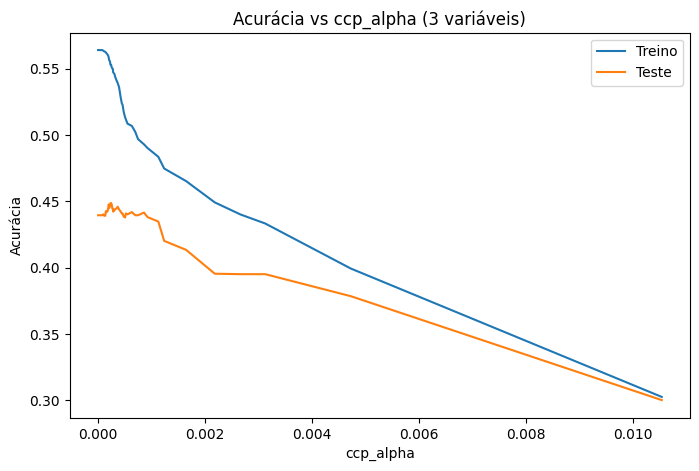

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(ccp_alphas_reduzido, acuracia_treino, label="Treino")
plt.plot(ccp_alphas_reduzido, acuracia_teste, label="Teste")

plt.xlabel("ccp_alpha")
plt.ylabel("Acurácia")
plt.title("Acurácia vs ccp_alpha (3 variáveis)")
plt.legend()

plt.show()

In [ ]:
indice_melhor = np.argmax(acuracia_teste)

melhor_alpha = ccp_alphas_reduzido[indice_melhor]
melhor_arvore = arvores[indice_melhor]

print("Melhor alpha:", melhor_alpha)
print("Melhor acurácia treino:", acuracia_treino[indice_melhor])
print("Melhor acurácia teste:", acuracia_teste[indice_melhor])

Melhor alpha: 0.00023944476959803082
Melhor acurácia treino: 0.5529107725788901
Melhor acurácia teste: 0.44859178825924667


In [ ]:
acuracia_teste[indice_melhor]

0.44859178825924667

provavelmente o que mantém o "acuracia_teste" em 0.44 é a quantidade limitada de variáveis, mas para confirmar vou rodar o valor do treino